# Parameter Optimization Playground

In [1]:
# Basic packages
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import math
from netCDF4 import Dataset

# DateTime packages
from matplotlib.dates import DateFormatter
from datetime import datetime, timedelta
import time
import matplotlib.dates as mdates

# Stats packages
import scipy
import PyCO2SYS as pyco2
import gsw
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import optuna

# Logistical packages
import requests
from importlib import reload
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import gc

# 1. Load in runs and calculate RMSE
## 1.1. Get path to all the file names

In [2]:
# ============================================================
# PATHS
# ============================================================

COST_DIR = Path("/Users/akbaskind/Desktop/COST_FILES")
OPT_DIR = Path("/Users/akbaskind/Desktop/Optimization")
FILE_LIST = OPT_DIR / "FileNames.xlsx"

## 1.2. Functions to calculate norm RMSE

$$
RMSD^{*'} = \text{sign}(\Delta \sigma)\sqrt{1 + {(\frac{\sigma_a}{\sigma_{\widehat{a}}})}^2 -2(\frac{\sigma_a}{\sigma_{\widehat{a}}}) \frac{\frac{1}{N} \sum_{n=1}^{N} (a_n - \overline{a})(\widehat{a_n} - \overline{\widehat{a}})}{\sigma_a \sigma_{\widehat{a}}}}
$$

From [Jolliff et al 2009](https://doi.org/10.1016/j.jmarsys.2008.05.014)

In [3]:
# ============================================================
# METRIC DEFINITIONS
# ============================================================

metric_info = {
    "Surface Temperature": ("temp_mod", "temp_obs"),
    "Bottom Temperature":  ("temp_mod", "temp_obs"),
    "Total Temperature":   ("temp_mod", "temp_obs"),

    "Surface Salinity": ("salt_mod", "salt_obs"),
    "Bottom Salinity":  ("salt_mod", "salt_obs"),
    "Total Salinity":   ("salt_mod", "salt_obs"),

    "Surface pH": ("pH_mod", "pH_obs"),
    "Bottom pH":  ("pH_mod", "pH_obs"),
    "Total pH":   ("pH_mod", "pH_obs"),

    "Surface Oxygen": ("oxygen_mod", "oxygen_obs"),
    "Bottom Oxygen":  ("oxygen_mod", "oxygen_obs"),
    "Total Oxygen":   ("oxygen_mod", "oxygen_obs"),

    "Surface NO3": ("NO3_mod", "NO3_obs"),
    "Bottom NO3":  ("NO3_mod", "NO3_obs"),
    "Total NO3":   ("NO3_mod", "NO3_obs"),

    "Surface NH4": ("NH4_mod", "NH4_obs"),
    "Bottom NH4":  ("NH4_mod", "NH4_obs"),
    "Total NH4":   ("NH4_mod", "NH4_obs"),

    "Surface Si": ("Si_mod", "Si_obs"),
    "Bottom Si":  ("Si_mod", "Si_obs"),
    "Total Si":   ("Si_mod", "Si_obs"),

    "Secchi Depth": ("SD_mod", "SD_obs"),
    "SOD": ("sed_o2_mod", "sed_o2_obs"),
    "Benthic NO3 Flux": ("sed_no3_mod", "sed_no3_obs"),
    "Benthic NH4 Flux": ("sed_nh4_mod", "sed_nh4_obs"),
}


# ============================================================
# OBSERVATIONAL ERROR
# ============================================================

def get_stderr(var_obs, obs_mean):

    if var_obs.startswith("sed"):
        return obs_mean

    elif var_obs.startswith("pH"):
        return 0.1

    elif var_obs.startswith("temp"):
        return 0.01

    elif var_obs.startswith("salt"):
        return 0.005 * obs_mean

    elif var_obs.startswith("oxy"):
        return 3.125

    elif var_obs.startswith("N"):
        return 0.1

    elif var_obs.startswith("Si"):
        return 0.1

    elif var_obs.startswith("SD"):
        return 0.2

    else:
        return 0


# ============================================================
# CALCULATE ONE RMSE*
# ============================================================

def calculate_rmse_star(ds, metric_name, var_mod, var_obs):
    
    if var_mod not in ds.variables or var_obs not in ds.variables:
        return np.nan

    # --------------------------------
    # Select depth
    # --------------------------------

    if metric_name.startswith("Surface"):

        mod = ds[var_mod].isel(Depth=0).values.ravel()
        obs = ds[var_obs].isel(Depth=0).values.ravel()

    elif metric_name.startswith("Bottom"):

        mod = ds[var_mod].isel(Depth=1).values.ravel()
        obs = ds[var_obs].isel(Depth=1).values.ravel()

    else:

        mod = ds[var_mod].values.ravel()
        obs = ds[var_obs].values.ravel()


    # --------------------------------
    # Means / standard deviations
    # --------------------------------

    mod_mean = np.nanmean(mod)
    obs_mean = np.nanmean(obs)

    std_mod = np.nanstd(mod)
    std_obs = np.nanstd(obs)


    # --------------------------------
    # Add observational uncertainty
    # --------------------------------

    stderr = get_stderr(var_obs, obs_mean)

    std_obs = np.sqrt(
        std_obs**2 +
        stderr**2
    )


    # --------------------------------
    # Correlation
    # --------------------------------

    covariance = (
        (mod - mod_mean) *
        (obs - obs_mean)
    )

    valid = ~np.isnan(covariance)

    N = valid.sum()

    if N == 0:
        return np.nan

    R = (
        covariance[valid].sum() /
        (std_mod * std_obs)
    )

    R = R / N


    # --------------------------------
    # Normalized standard deviation
    # --------------------------------

    std_norm = std_mod / std_obs


    # --------------------------------
    # Sign
    # --------------------------------

    sign = np.sign(std_mod - std_obs)


    # --------------------------------
    # RMSD*'
    # --------------------------------

    inside = (
        1 +
        std_norm**2 -
        2 * std_norm * R
    )

    # Protect against tiny numerical negatives
    if inside < 0:
        inside = abs(inside)

    rmsd_star = np.sqrt(inside) * sign

    return rmsd_star

## 1.3. Get all the file names

In [4]:
# ============================================================
# READ FILE LIST
# ============================================================

runs = pd.read_excel(FILE_LIST)

runs = runs[["Run Name", "Cost File"]].dropna(subset=["Run Name", "Cost File"])

print(f"Found {len(runs)} model runs.")

Found 96 model runs.


## 1.4. Calculate norm RMSE for one run at a time

In [5]:
# ============================================================
# PROCESS ONE MODEL RUN AT A TIME
# ============================================================

results = []
missing_cost_files = []

for i, row in runs.iterrows():

    run_name = row["Run Name"]
    cost_file = row["Cost File"]

    file_path = COST_DIR / cost_file

    print(
        f"\n[{len(results)+1}/{len(runs)}] "
        f"Processing {run_name}"
    )

    print(f"  {file_path.name}")

    # Storage for this ONE run
    run_results = {
        "Run Name": run_name,
        "Cost File": cost_file
    }

    try:

        # Open only this dataset
        with xr.open_dataset(file_path) as ds:

            for metric_name, (var_mod, var_obs) in metric_info.items():

                rmse = calculate_rmse_star(
                    ds,
                    metric_name,
                    var_mod,
                    var_obs
                )

                run_results[metric_name] = rmse

                # print(
                #     f"    {metric_name}: "
                #     f"{rmse:.4f}"
                # )

        # Dataset is CLOSED here

        run_results["Status"] = "Success"

    except Exception as e:

        print(f"  ERROR: {e}")

        run_results["Status"] = f"ERROR: {e}"
        
        missing_cost_files.append(file_path)

    results.append(run_results)

    # Optional additional cleanup
    gc.collect()


[1/96] Processing A13
  A13.nc

[2/96] Processing DU_Mar16
  DU_Mar16.nc

[3/96] Processing DU
  DU.nc

[4/96] Processing A17
  A17.nc

[5/96] Processing C11
  C11.nc

[6/96] Processing A16
  A16.nc

[7/96] Processing C10
  C10.nc

[8/96] Processing A12
  A12.nc

[9/96] Processing 2005_CTRL
  2005_CTRL.nc
  ERROR: [Errno 2] No such file or directory: '/Users/akbaskind/Desktop/COST_FILES/2005_CTRL.nc'

[10/96] Processing D10
  D10.nc

[11/96] Processing C5
  C5.nc

[12/96] Processing A1
  A1.nc

[13/96] Processing LHS_5
  LHS_5.nc

[14/96] Processing D14
  D14.nc

[15/96] Processing LHS_7a
  LHS_7a.nc

[16/96] Processing C1
  C1.nc

[17/96] Processing D4
  D4.nc

[18/96] Processing A5
  A5.nc

[19/96] Processing LHS_1
  LHS_1.nc

[20/96] Processing C13_2005
  C13_2005.nc

[21/96] Processing D15
  D15.nc

[22/96] Processing D5
  D5.nc

[23/96] Processing A4
  A4.nc

[24/96] Processing LHS_12
  LHS_12.nc

[25/96] Processing D11
  D11.nc

[26/96] Processing A18
  A18.nc

[27/96] Processin

In [6]:
RMSE_ = pd.DataFrame(results)

In [7]:
# Drop any runs where the file did not exist
RMSE_ = RMSE_[RMSE_["Status"] == "Success"].reset_index(drop=True)

In [8]:
missing_cost_files

[PosixPath('/Users/akbaskind/Desktop/COST_FILES/2005_CTRL.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/C4.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/A7.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/A3.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/C13.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/LHS17_2005.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/LHS16_2005.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/LHS19_2005.nc'),
 PosixPath('/Users/akbaskind/Desktop/COST_FILES/LHS18_2005.nc')]

# 2. Get parameter values



## 2.1. Get file paths and parameter names

In [9]:
# ============================================================
# PATHS
# ============================================================

FILE_LIST = OPT_DIR / "FileNames.xlsx"
PARAMETER_LIST = OPT_DIR / "ParameterList copy.csv"


# ============================================================
# READ RUN / FILE NAMES
# ============================================================

runs = pd.read_excel(
    FILE_LIST,
    usecols=["Run Name", "Station File"]
)

runs = runs.dropna(
    subset=["Run Name", "Station File"]
)


# ============================================================
# READ PARAMETER NAMES
# ============================================================

parameter_names = (
    pd.read_csv(PARAMETER_LIST)["Parameter Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)

print(f"{len(runs)} station files")
print(f"{len(parameter_names)} parameters")

96 station files
74 parameters


## 2.2. Function to extract parameter values

In [10]:
def get_parameter_values(ds, parameter_name):

    # Parameter doesn't exist in this file
    # Don't create a new scalar-named column
    if parameter_name not in ds.variables:
        return {}

    var = ds.variables[parameter_name]

    try:

        # --------------------------------
        # Scalar parameter
        # --------------------------------
        if var.ndim == 0:

            value = var[...]

            if np.ma.is_masked(value):
                value = np.nan

            return {
                parameter_name: np.asarray(value).item()
            }

        # --------------------------------
        # Parameter with dimensions
        # --------------------------------
        values = np.asarray(var[:]).squeeze()

        # Squeezes down to a scalar
        if values.ndim == 0:

            return {
                parameter_name: values.item()
            }

        # --------------------------------
        # One-dimensional parameter
        # --------------------------------
        if values.ndim == 1:

            dim_name = var.dimensions[0]

            return {
                f"{parameter_name}_{dim_name}{i}": value
                for i, value in enumerate(values)
            }

        # --------------------------------
        # Anything else
        # --------------------------------
        values = values.ravel()

        return {
            f"{parameter_name}_{i}": value
            for i, value in enumerate(values)
        }

    except Exception as e:

        print(
            f"    Could not read {parameter_name}: {e}"
        )

        return {}

## 2.3. Extract parameter values one file at a time

In [11]:
# ============================================================
# EXTRACT PARAMETERS ONE FILE AT A TIME
# ============================================================

parameter_results = []

missing_station_files = []

for n, (_, row) in enumerate(runs.iterrows(), start=1):

    run_name = row["Run Name"]
    station_file = row["Station File"]

    file_path = COST_DIR / station_file

    print(
        f"[{n}/{len(runs)}] "
        f"{run_name} -- {file_path.name}"
    )

    # Only small scalar values are stored here
    run_parameters = {
        "Run Name": run_name,
        "Station File": station_file
    }

    try:

        # Open ONE large file
        with Dataset(file_path, mode="r") as ds:

            for parameter in parameter_names:

                parameter_values = get_parameter_values(
                    ds,
                    parameter
                )

                run_parameters.update(parameter_values)

        run_parameters["Parameter Status"] = "Success"

    except Exception as e:

        print(f"    ERROR: {e}")

        # Fill all parameters with NaN if file couldn't be opened
        for parameter in parameter_names:
            run_parameters.setdefault(
                parameter,
                np.nan
            )

        run_parameters["Parameter Status"] = f"ERROR: {e}"
        
        missing_station_files.append(file_path.name)

    parameter_results.append(run_parameters)

    gc.collect()


# ============================================================
# FINAL DATAFRAME
# ============================================================

DF_parameters = pd.DataFrame(parameter_results)

# Safety cleanup
DF_parameters = DF_parameters.dropna(
    axis=1,
    how="all"
)

[1/96] A13 -- ocean_sta_A13.nc
[2/96] DU_Mar16 -- ocean_sta_DU_Mar16.nc
[3/96] DU -- ocean_sta_DU.nc
[4/96] A17 -- ocean_sta_A17.nc
[5/96] C11 -- ocean_sta_C11.nc
[6/96] A16 -- ocean_sta_A16.nc
[7/96] C10 -- ocean_sta_C10.nc
[8/96] A12 -- ocean_sta_A12.nc
[9/96] 2005_CTRL -- ocean_sta_2005_CTRL.nc
[10/96] D10 -- ocean_sta_D10.nc
[11/96] C5 -- ocean_sta_C5.nc
[12/96] A1 -- ocean_sta_A1.nc
[13/96] LHS_5 -- ocean_sta_LHS_5.nc
[14/96] D14 -- ocean_sta_D14.nc
[15/96] LHS_7a -- ocean_sta_LHS_7a.nc
[16/96] C1 -- ocean_sta_C1.nc
[17/96] D4 -- ocean_sta_D4.nc
[18/96] A5 -- ocean_sta_A5.nc
[19/96] LHS_1 -- ocean_sta_LHS_1.nc
[20/96] C13_2005 -- ocean_sta_C13_2005.nc
[21/96] D15 -- ocean_sta_D15.nc
[22/96] D5 -- ocean_sta_D5.nc
[23/96] A4 -- ocean_sta_A4.nc
[24/96] LHS_12 -- ocean_sta_LHS_12.nc
[25/96] D11 -- ocean_sta_D11.nc
[26/96] A18 -- ocean_sta_A18.nc
[27/96] C4 -- ocean_sta_C4.nc
[28/96] C5_2005 -- ocean_sta_C5_2005.nc
[29/96] LHS20_2005 -- ocean_sta_LHS20_2005.nc
[30/96] LHS_16 -- ocean_s

In [12]:
missing_station_files

['ocean_sta_C13.nc', 'ocean_sta_LHS19_2005.nc', 'ocean_sta_LHS18_2005.nc']

# 3. Combine the `RMSE_` and `DF_parameters` dataframes

In [13]:
DF_parameters = DF_parameters.drop_duplicates(subset=["Run Name"])
RMSE_ = RMSE_.drop_duplicates(subset=["Run Name"])

In [14]:
DF_opt = DF_parameters.merge(RMSE_,
                             on="Run Name",
                             how="inner",
                             validate="one_to_one")

print("DF_parameters:", DF_parameters.shape)
print("RMSE_:", RMSE_.shape)
print("DF_opt:", DF_opt.shape)

DF_opt.head()

DF_parameters: (95, 89)
RMSE_: (86, 28)
DF_opt: (86, 116)


,Run Name,Station File,reg1,reg2,gmaxs1,gmaxs2,rrb1,rrb2,rrg1,rrg2,...,Bottom NH4,Total NH4,Surface Si,Bottom Si,Total Si,Secchi Depth,SOD,Benthic NO3 Flux,Benthic NH4 Flux,Status
0,A13,ocean_sta_A13.nc,0.2,0.10,5.0,7.0,0.3,0.3,0.2,0.2,...,-1.048993,-1.016984,-0.901112,-0.864847,-0.886292,-1.099313,-0.976099,-1.185369,-1.136942,Success
1,DU_Mar16,ocean_sta_DU_Mar16.nc,0.1,0.05,3.0,5.0,0.2,0.2,0.1,0.1,...,4.198847,3.711230,1.197260,-1.112463,1.265820,-0.751055,-1.052831,0.475755,-0.999623,Success
2,DU,ocean_sta_DU.nc,0.1,0.05,3.0,5.0,0.2,0.2,0.1,0.1,...,4.427807,4.052713,1.217729,-1.068504,1.303279,-0.743201,-1.054419,0.382028,-0.994217,Success
3,A17,ocean_sta_A17.nc,0.2,0.10,5.0,7.0,0.3,0.3,0.2,0.2,...,-0.988976,-0.929465,-0.795684,-0.919978,-0.848567,-1.336912,NaN,NaN,NaN,Success
4,C11,ocean_sta_C11.nc,0.1,0.05,4.5,6.0,0.2,0.2,0.1,0.1,...,-1.040742,-0.967404,-0.983584,-1.235111,-1.077087,-1.129166,-0.950250,-1.015962,-0.915260,Success


# 4. Idenitfy parameters and RMSEs

In [15]:
include_benthic = True
exclude_some_benthic = True

benthic_cols = ["SOD",
                "Benthic NO3 Flux",
                "Benthic NH4 Flux",
               ]

some_benthic_cols = ["Benthic NO3 Flux",
                     "Benthic NH4 Flux",
                    ]

parameter_cols = [col for col in DF_parameters.columns
                  if col not in ["Run Name", "Station File", "Parameter Status"]]

rmse_cols = [col for col in RMSE_.columns
             if col not in ["Run Name", "Cost File", "Status"]]

if include_benthic:
    if exclude_some_benthic:
        required_rmse_cols = [col for col in rmse_cols
                              if col not in some_benthic_cols]
    else:
        required_rmse_cols = rmse_cols
else:
    required_rmse_cols = [col for col in rmse_cols
                          if col not in benthic_cols]
    
DF_opt_clean = DF_opt.dropna(subset=required_rmse_cols).copy()

print("Original runs:", len(DF_opt))
print("Runs retained:", len(DF_opt_clean))
print("Runs removed:", len(DF_opt) - len(DF_opt_clean))

print("\nObjectives being required:")
print(required_rmse_cols)

Original runs: 86
Runs retained: 58
Runs removed: 28

Objectives being required:
['Surface Temperature', 'Bottom Temperature', 'Total Temperature', 'Surface Salinity', 'Bottom Salinity', 'Total Salinity', 'Surface pH', 'Bottom pH', 'Total pH', 'Surface Oxygen', 'Bottom Oxygen', 'Total Oxygen', 'Surface NO3', 'Bottom NO3', 'Total NO3', 'Surface NH4', 'Bottom NH4', 'Total NH4', 'Surface Si', 'Bottom Si', 'Total Si', 'Secchi Depth', 'SOD']


In [16]:
# Identify runs with and without complete benthic RMSE data
has_benthic = DF_opt[benthic_cols].notna().all(axis=1)

print("\nRuns WITH benthic data:")
print(DF_opt.loc[has_benthic, "Run Name"].tolist())

print("\nRuns WITHOUT benthic data:")
print(DF_opt.loc[~has_benthic, "Run Name"].tolist())

print("\nBenthic data summary:")
print("Runs with benthic data:", has_benthic.sum())
print("Runs without benthic data:", (~has_benthic).sum())


Runs WITH benthic data:
['A13', 'DU_Mar16', 'DU', 'C11', 'C10', 'A12', 'D10', 'C5', 'A1', 'D14', 'LHS_7a', 'C1', 'D4', 'C13_2005', 'A4', 'D11', 'C5_2005', 'LHS20_2005', 'C3', 'D6', 'D12', 'C9_2005', 'C7', 'D13', 'C6', 'D10-2', 'C2', 'LHS_7b', 'D7', 'C9', 'A11', 'DUMar26', 'D8', 'A10', 'D9', 'A8', 'C8', 'C12', 'LHS9_2005', 'LHS14_2005', 'LHS1_2005', 'LHS8_2005', 'LHS3_2005', 'LHS2_2005', 'LHS7_2005', 'LHS13_2005', 'LHS12_2005', 'LHS6_2005', 'LHS10_2005', 'LHS4_2005', 'LHS5_2005', 'LHS11_2005', 'LHS14_2005_OLD', 'LHS16_2005_OLD', 'LHS15_2005', 'LHS17_2005_OLD', 'LHS18_2005_OLD', 'LHS19_2005_OLD']

Runs WITHOUT benthic data:
['A17', 'A16', 'LHS_5', 'A5', 'LHS_1', 'D15', 'D5', 'LHS_12', 'A18', 'LHS_16', 'LHS_4', 'D16', 'LHS_3', 'LHS_11', 'LHS_7', 'A2', 'LHS_6', 'D17', 'A6', 'LHS_2', 'LHS_10', 'A15', 'LHS_9', 'D18', 'A9', 'D19', 'A14', 'LHS_8']

Benthic data summary:
Runs with benthic data: 58
Runs without benthic data: 28


## 4.1. Check for missing values

In [17]:
print("Missing values per RMSE column:")
print(DF_opt_clean[required_rmse_cols].isna().sum())

print("\nAll values finite:")
print(np.isfinite(DF_opt_clean[required_rmse_cols]).all())

Missing values per RMSE column:
Surface Temperature    0
Bottom Temperature     0
Total Temperature      0
Surface Salinity       0
Bottom Salinity        0
Total Salinity         0
Surface pH             0
Bottom pH              0
Total pH               0
Surface Oxygen         0
Bottom Oxygen          0
Total Oxygen           0
Surface NO3            0
Bottom NO3             0
Total NO3              0
Surface NH4            0
Bottom NH4             0
Total NH4              0
Surface Si             0
Bottom Si              0
Total Si               0
Secchi Depth           0
SOD                    0
dtype: int64

All values finite:
Surface Temperature    True
Bottom Temperature     True
Total Temperature      True
Surface Salinity       True
Bottom Salinity        True
Total Salinity         True
Surface pH             True
Bottom pH              True
Total pH               True
Surface Oxygen         True
Bottom Oxygen          True
Total Oxygen           True
Surface NO3            T

# 5. finalize objectives to analyze

In [18]:
rmse_corr = DF_opt_clean[required_rmse_cols].corr(method="spearman")

display(rmse_corr.round(2))

,Surface Temperature,Bottom Temperature,Total Temperature,Surface Salinity,Bottom Salinity,Total Salinity,Surface pH,Bottom pH,Total pH,Surface Oxygen,...,Bottom NO3,Total NO3,Surface NH4,Bottom NH4,Total NH4,Surface Si,Bottom Si,Total Si,Secchi Depth,SOD
Surface Temperature,1.00,-0.02,0.17,0.84,-0.02,0.84,0.17,0.22,0.18,-0.11,...,0.06,0.23,0.06,0.11,0.10,0.64,0.17,0.52,-0.02,-0.20
Bottom Temperature,-0.02,1.00,0.81,0.02,0.89,0.01,0.22,0.26,0.24,0.45,...,0.81,0.65,0.62,0.13,0.10,0.12,-0.40,-0.19,0.79,0.32
Total Temperature,0.17,0.81,1.00,0.22,0.71,0.21,0.39,0.45,0.41,0.44,...,0.61,0.81,0.44,-0.02,-0.05,0.31,-0.34,-0.01,0.71,0.38
Surface Salinity,0.84,0.02,0.22,1.00,0.11,1.00,-0.02,-0.04,-0.02,-0.34,...,-0.02,0.16,0.29,-0.04,0.28,0.51,0.00,0.38,-0.00,-0.28
Bottom Salinity,-0.02,0.89,0.71,0.11,1.00,0.07,0.11,0.14,0.13,0.39,...,0.70,0.53,0.69,0.02,0.16,0.06,-0.44,-0.23,0.66,0.19
Total Salinity,0.84,0.01,0.21,1.00,0.07,1.00,-0.01,-0.03,-0.01,-0.34,...,-0.01,0.16,0.28,-0.03,0.27,0.50,0.00,0.38,0.00,-0.27
Surface pH,0.17,0.22,0.39,-0.02,0.11,-0.01,1.00,0.96,1.00,0.51,...,0.30,0.50,-0.33,0.25,-0.44,0.41,0.03,0.22,0.39,0.60
Bottom pH,0.22,0.26,0.45,-0.04,0.14,-0.03,0.96,1.00,0.97,0.60,...,0.33,0.53,-0.34,0.22,-0.47,0.46,0.09,0.29,0.38,0.58
Total pH,0.18,0.24,0.41,-0.02,0.13,-0.01,1.00,0.97,1.00,0.53,...,0.30,0.50,-0.33,0.24,-0.44,0.42,0.04,0.24,0.38,0.59
Surface Oxygen,-0.11,0.45,0.44,-0.34,0.39,-0.34,0.51,0.60,0.53,1.00,...,0.57,0.56,-0.09,0.13,-0.37,0.04,-0.14,-0.21,0.47,0.66


## 5.1. Since the total RMSEs are redundant strip them for now

Also, since the sign of the normalized RMSE from Jolliff et al 2009 is not necessarily positive, making it difficult to determine if better results are minimized or maximized, we take the absolute value of all the nRMSEs for an objective nRMSE.

In [19]:
active_rmse_cols = [COL for COL in required_rmse_cols if not COL.startswith("Total")]

active_objective_cols = []

for col in active_rmse_cols:
    new_col = f"{col} Objective"
    DF_opt_clean[new_col] = DF_opt_clean[col].abs()
    active_objective_cols.append(new_col)
    
DF_opt_clean[active_objective_cols].describe().T[["min",
                                                  "25%",
                                                  "50%",
                                                  "75%",
                                                  "max"]]

,min,25%,50%,75%,max
Surface Temperature Objective,0.263057,0.268273,0.291406,0.322477,0.361455
Bottom Temperature Objective,0.250133,0.257954,0.259403,0.439991,0.648028
Surface Salinity Objective,0.916436,0.922359,1.067236,1.136251,4.251452
Bottom Salinity Objective,0.206674,0.230392,0.743742,1.070108,2.694552
Surface pH Objective,0.897703,0.966301,1.112022,1.307070,6.124632
Bottom pH Objective,0.874077,0.922573,1.106498,1.234036,7.285670
Surface Oxygen Objective,0.560586,0.631104,0.728630,0.812271,0.863538
Bottom Oxygen Objective,0.635837,0.662653,0.736563,0.777576,1.159501
Surface NO3 Objective,0.741403,0.774108,1.269246,1.686213,4.156361
Bottom NO3 Objective,0.803982,0.838033,1.283814,1.633179,3.022346


# 6. Which parameters actually varied?

## 6.1. Isolate parameters that varied

In [20]:
parameter_variation = DF_opt_clean[parameter_cols].nunique().sort_values()

varied_parameter_cols = parameter_variation[
    parameter_variation > 1
].index.tolist()

print("Parameters that varied:", len(varied_parameter_cols))
print("Parameters that never varied:",
      (parameter_variation == 1).sum())
print(varied_parameter_cols)

Parameters that varied: 37
Parameters that never varied: 49
['bgamma0', 'bUmax_nspc0', 'wsp', 'bfs_nspc1', 'bfs_nspc0', 'aksio4s2', 'pis2', 'akz1', 'aknh4s1', 'akno3s1', 'reg2', 'reg1', 'bgamma3', 'bgamma6', 'bgamma5s', 'rrb1', 'rrb2', 'rrg2', 'rrg1', 'Chl2cs1_m', 'Chl2cs2_m', 'wsdsi', 'bgamma4', 'akz2', 'amaxs1', 'gmaxs2', 'gmaxs1', 'amaxs2', 'akno3s2', 'beta2', 'beta1', 'bnit', 'bgamma7', 'wsd', 'bgamma5', 'bdenit', 'bUmax_nspc1']


### 6.1.1. Diagnostic table of parameter variations

In [21]:
parameter_summary = DF_opt_clean[varied_parameter_cols].agg(["min", "max", "nunique"]).T

display(parameter_summary)

,min,max,nunique
bgamma0,0.02500,0.050000,2.0
bUmax_nspc0,0.05000,0.100000,2.0
wsp,0.30000,0.400000,2.0
bfs_nspc1,0.35000,0.650000,2.0
bfs_nspc0,0.35000,0.650000,2.0
aksio4s2,1.00000,2.000000,2.0
pis2,1.59000,5.590000,2.0
akz1,0.25000,1.000000,3.0
aknh4s1,0.01000,0.100000,3.0
akno3s1,0.75000,1.500000,3.0


## 6.2. Clean dataframe for just parameters that varied and the objectives we can evaluate

In [22]:
DF_optuna = DF_opt_clean[["Run Name"] +
                         varied_parameter_cols +
                         active_objective_cols].copy()

print(DF_optuna.shape)
display(DF_optuna.head())

(58, 54)


,Run Name,bgamma0,bUmax_nspc0,wsp,bfs_nspc1,bfs_nspc0,aksio4s2,pis2,akz1,aknh4s1,...,Surface Oxygen Objective,Bottom Oxygen Objective,Surface NO3 Objective,Bottom NO3 Objective,Surface NH4 Objective,Bottom NH4 Objective,Surface Si Objective,Bottom Si Objective,Secchi Depth Objective,SOD Objective
0,A13,0.025,0.05,0.3,0.35,0.65,1.0,1.59,1.0,0.10,...,0.600216,0.669861,0.746437,0.830394,0.989431,1.048993,0.901112,0.864847,1.099313,0.976099
1,DU_Mar16,0.025,0.05,0.4,0.65,0.35,2.0,1.59,0.5,0.10,...,0.697291,0.946075,3.925145,2.479664,3.344402,4.198847,1.197260,1.112463,0.751055,1.052831
2,DU,0.025,0.05,0.4,0.65,0.35,2.0,1.59,0.5,0.10,...,0.761560,1.045176,4.156361,2.105985,3.734630,4.427807,1.217729,1.068504,0.743201,1.054419
4,C11,0.025,0.05,0.4,0.65,0.35,2.0,1.59,0.5,0.01,...,0.734506,0.754195,0.807021,0.886873,0.899166,1.040742,0.983584,1.235111,1.129166,0.950250
6,C10,0.025,0.05,0.4,0.65,0.35,2.0,1.59,0.5,0.05,...,0.693142,0.737725,0.813169,0.856909,0.934474,1.083954,1.030878,1.265556,0.982595,0.950236


# 7. Add in cost in place of priority score

## 7.1. Function to calculate cost

In [23]:
cost_components = {"Surface Temperature": "temperature_cost",
                   "Bottom Temperature": "temperature_cost",
                   "Surface Salinity": "salt_cost",
                   "Bottom Salinity": "salt_cost",
                   "Surface pH": "pH_cost",
                   "Bottom pH": "pH_cost", 
                   "Surface Oxygen": "oxygen_cost",
                   "Bottom Oxygen": "oxygen_cost",
                   "Surface NO3": "NO3_cost",
                   "Bottom NO3": "NO3_cost",
                   "Surface NH4": "NH4_cost",
                   "Bottom NH4": "NH4_cost",
                   "Surface Si": "Si_cost",
                   "Bottom Si": "Si_cost",
                   "Secchi Depth": "SD_cost",
                   "SOD": "sed_o2_cost",
                   "Benthic NO3 Flux": "sed_no3_cost",
                   "Benthic NH4 Flux": "sed_nh4_cost"
                  }

cost_weights    = {"Surface Temperature": 1,
                   "Bottom Temperature": 1,
                   "Surface Salinity": 1,
                   "Bottom Salinity": 1,
                   "Surface pH": 1,
                   "Bottom pH": 1, 
                   "Surface Oxygen": 1,
                   "Bottom Oxygen": 1,
                   "Surface NO3": 1,
                   "Bottom NO3": 1,
                   "Surface NH4": 1,
                   "Bottom NH4": 1,
                   "Surface Si": 1,
                   "Bottom Si": 1,
                   "Secchi Depth": 1,
                   "SOD": 1,
                   "Benthic NO3 Flux": 1,
                   "Benthic NH4 Flux": 1
                  }

In [24]:
def calculate_cost(ds, active_rmse_cols, cost_components, cost_weights):
    
    total_cost = 0
    
    for cost, key in cost_components.items():
        if cost in active_rmse_cols:
            
            if cost.startswith("Surface"):
                weight = cost_weights[cost]
                cost_comp = float(ds[key][0]) * weight*weight
            elif cost.startswith("Bottom"):
                weight = cost_weights[cost]
                cost_comp = float(ds[key][0]) * weight*weight
            else:
                weight = cost_weights[cost]
                cost_comp = float(ds[key]) * weight*weight
                
            total_cost = total_cost + cost_comp
    return total_cost

## 7.2. Calculate cost one file at a time

In [25]:
# ============================================================
# PROCESS ONE MODEL RUN AT A TIME
# ============================================================

results_cost = []
missing_cost_files = []

runs = pd.read_excel(FILE_LIST)
runs = runs[["Run Name", "Cost File"]].dropna(subset=["Run Name", "Cost File"])

for i, row in runs.iterrows():

    run_name = row["Run Name"]
    cost_file = row["Cost File"]

    file_path = COST_DIR / cost_file

    print(
        f"\n[{len(results_cost)+1}/{len(runs)}] "
        f"Processing {run_name}"
    )

    print(f"  {file_path.name}")

    # Storage for this ONE run
    run_results_cost = {
        "Run Name": run_name,
        "Cost File": cost_file
    }

    try:

        # Open only this dataset
        with xr.open_dataset(file_path) as ds:

            cost = calculate_cost(ds, active_rmse_cols, cost_components, cost_weights)
            run_results_cost["Cost"] = cost

        run_results_cost["Status"] = "Success"

    except Exception as e:

        print(f"  ERROR: {e}")

        run_results_cost["Status"] = f"ERROR: {e}"
        
        missing_cost_files.append(file_path)

    results_cost.append(run_results_cost)

    # Optional additional cleanup
    gc.collect()


[1/96] Processing A13
  A13.nc

[2/96] Processing DU_Mar16
  DU_Mar16.nc

[3/96] Processing DU
  DU.nc

[4/96] Processing A17
  A17.nc
  ERROR: "No variable named 'sed_o2_cost'. Did you mean one of ('salt_cost',)?"

[5/96] Processing C11
  C11.nc

[6/96] Processing A16
  A16.nc
  ERROR: "No variable named 'sed_o2_cost'. Did you mean one of ('salt_cost',)?"

[7/96] Processing C10
  C10.nc

[8/96] Processing A12
  A12.nc

[9/96] Processing 2005_CTRL
  2005_CTRL.nc
  ERROR: [Errno 2] No such file or directory: '/Users/akbaskind/Desktop/COST_FILES/2005_CTRL.nc'

[10/96] Processing D10
  D10.nc

[11/96] Processing C5
  C5.nc

[12/96] Processing A1
  A1.nc

[13/96] Processing LHS_5
  LHS_5.nc
  ERROR: "No variable named 'sed_o2_cost'. Did you mean one of ('salt_cost',)?"

[14/96] Processing D14
  D14.nc

[15/96] Processing LHS_7a
  LHS_7a.nc

[16/96] Processing C1
  C1.nc

[17/96] Processing D4
  D4.nc

[18/96] Processing A5
  A5.nc
  ERROR: "No variable named 'sed_o2_cost'. Did you mean on

In [26]:
cost = pd.DataFrame(results_cost)
cost = cost.drop_duplicates(subset=["Run Name"])
print("Number of costs:", len(cost))

Number of costs: 95


## 7.3. Add cost to `DF_optuna` and rank by cost

In [27]:
DF_optuna = (
    DF_optuna
    .drop(columns=["Cost"], errors="ignore")
    .merge(
        cost[["Run Name", "Cost"]],
        on="Run Name",
        how="left"
    )
)

print("Number of runs:", len(DF_optuna))

Number of runs: 58


### 7.3.1. Drop unreasonably large costs

In [28]:
print("Dropping any run with a cost over 200, as that suggests something went wrong.\n")
old_len = len(DF_optuna)
DF_optuna = DF_optuna[DF_optuna["Cost"] < 200].reset_index(drop = True)
new_len = len(DF_optuna)
print("Number of runs:", len(DF_optuna))
print("Number of runs dropped:", old_len - new_len)

del old_len, new_len

Dropping any run with a cost over 200, as that suggests something went wrong.

Number of runs: 38
Number of runs dropped: 20


### 7.3.2. Reidentify parameters that varied

In [29]:
parameter_variation = DF_optuna[varied_parameter_cols].nunique().sort_values()

varied_parameter_cols = parameter_variation[
    parameter_variation > 1
].index.tolist()

print("Parameters that varied:", len(varied_parameter_cols))
print("Parameters that never varied:",
      (parameter_variation == 1).sum())
print(varied_parameter_cols)

Parameters that varied: 32
Parameters that never varied: 5
['bgamma0', 'wsp', 'bUmax_nspc0', 'akz1', 'reg1', 'bgamma3', 'reg2', 'bfs_nspc0', 'aksio4s2', 'pis2', 'bfs_nspc1', 'beta2', 'beta1', 'amaxs2', 'bgamma6', 'akz2', 'bgamma5s', 'akno3s1', 'aknh4s1', 'bgamma4', 'wsdsi', 'Chl2cs2_m', 'Chl2cs1_m', 'gmaxs2', 'gmaxs1', 'akno3s2', 'bnit', 'bgamma7', 'bgamma5', 'bdenit', 'wsd', 'bUmax_nspc1']


### 7.3.3. Rank by cost

In [30]:
DF_cost_ranked = DF_optuna.sort_values("Cost")

DF_optuna = DF_optuna.reset_index(drop=True)

display(DF_cost_ranked[["Run Name", "Cost"] +
                           active_objective_cols].head(10))


,Run Name,Cost,Surface Temperature Objective,Bottom Temperature Objective,Surface Salinity Objective,Bottom Salinity Objective,Surface pH Objective,Bottom pH Objective,Surface Oxygen Objective,Bottom Oxygen Objective,Surface NO3 Objective,Bottom NO3 Objective,Surface NH4 Objective,Bottom NH4 Objective,Surface Si Objective,Bottom Si Objective,Secchi Depth Objective,SOD Objective
16,C8,26.029243,0.263057,0.250133,0.961791,0.241491,1.005129,1.107238,0.695054,0.736282,0.817069,0.851462,0.887080,1.047896,0.923318,1.195739,1.171852,0.951018
10,C7,26.084536,0.263057,0.250133,0.961791,0.241491,1.002185,1.108820,0.687085,0.735746,0.812103,0.842932,0.864269,1.037198,0.896843,1.169015,1.196162,0.951128
17,C12,27.965203,0.263057,0.250133,0.961791,0.241491,0.997711,1.105758,0.724020,0.746249,0.817556,0.876828,0.895194,1.039780,0.966682,1.224394,1.140839,0.950503
0,C11,28.036106,0.263057,0.250133,0.961791,0.241491,1.004412,1.139155,0.734506,0.754195,0.807021,0.886873,0.899166,1.040742,0.983584,1.235111,1.129166,0.950250
15,DUMar26,28.653163,0.327286,0.428494,1.205847,0.655344,1.009433,1.083146,0.716933,0.903888,4.132480,2.209251,3.887062,4.305971,1.110033,1.097962,0.756065,1.059896
14,C9,29.457182,0.263057,0.250133,0.961791,0.241491,1.011990,1.126721,0.693554,0.739349,0.805084,0.858677,0.939848,1.085412,1.022438,1.260686,0.996225,0.950902
1,C10,29.516924,0.263057,0.250133,0.961791,0.241491,1.011170,1.132326,0.693142,0.737725,0.813169,0.856909,0.934474,1.083954,1.030878,1.265556,0.982595,0.950236
33,LHS16_2005_OLD,30.963248,0.294443,0.263139,1.271381,0.931124,1.389862,1.276393,0.863538,0.868429,1.962027,1.808828,0.946909,2.019241,0.816761,0.869264,0.930185,1.948990
11,C6,33.195317,0.291406,0.256116,1.231046,0.832139,1.124185,1.096180,0.836376,0.812332,1.272166,1.316316,0.778513,1.093733,0.772797,0.870441,1.117685,1.087428
7,LHS20_2005,34.634047,0.294443,0.263139,1.271381,0.931124,1.222218,1.174802,0.770497,0.804581,1.228126,1.240247,0.833987,1.383791,0.884844,0.928637,1.003755,1.529881


# 8. Define parameter distributions

In [31]:
distributions = {}

for parameter in varied_parameter_cols:
    distributions[parameter] = optuna.distributions.FloatDistribution(
        low=DF_optuna[parameter].min(),
        high=DF_optuna[parameter].max())
    
for parameter, distribution in distributions.items():
    print(parameter, distribution)

bgamma0 FloatDistribution(high=0.05, log=False, low=0.025, step=None)
wsp FloatDistribution(high=0.4, log=False, low=0.3, step=None)
bUmax_nspc0 FloatDistribution(high=0.1, log=False, low=0.05, step=None)
akz1 FloatDistribution(high=1.0, log=False, low=0.5, step=None)
reg1 FloatDistribution(high=0.2, log=False, low=0.1, step=None)
bgamma3 FloatDistribution(high=0.25, log=False, low=0.1, step=None)
reg2 FloatDistribution(high=0.1, log=False, low=0.05, step=None)
bfs_nspc0 FloatDistribution(high=0.65, log=False, low=0.35, step=None)
aksio4s2 FloatDistribution(high=2.0, log=False, low=1.0, step=None)
pis2 FloatDistribution(high=5.59, log=False, low=1.59, step=None)
bfs_nspc1 FloatDistribution(high=0.65, log=False, low=0.35, step=None)
beta2 FloatDistribution(high=1.75, log=False, low=0.3, step=None)
beta1 FloatDistribution(high=2.25, log=False, low=0.5, step=None)
amaxs2 FloatDistribution(high=0.11, log=False, low=0.1, step=None)
bgamma6 FloatDistribution(high=0.1, log=False, low=0.005, s

# 9. Create multi-objective optuna study

In [32]:
study = optuna.create_study(directions=["minimize"] * len(active_objective_cols))

study.set_metric_names(active_objective_cols)

# Verify 
print("Number of objectives:", len(study.directions))
print("Metric names:")
print(study.metric_names)

print("\nNumber of trials currently in study:", len(study.trials))

for _, row in DF_optuna.iterrows():

    params = {parameter: float(row[parameter])
              for parameter in varied_parameter_cols}

    values = [float(row[col])
              for col in active_objective_cols]

    trial = optuna.trial.create_trial(params=params,
                                      distributions=distributions,
                                      values=values,
                                      user_attrs={"Run Name": row["Run Name"]})

    study.add_trial(trial)

print("Number of trials added:", len(study.trials))

[I 2026-09-04 07:58:59,456] A new study created in memory with name: no-name-498908f5-3b8e-4789-8c35-e2675b55adf6


Number of objectives: 16
Metric names:
['Surface Temperature Objective', 'Bottom Temperature Objective', 'Surface Salinity Objective', 'Bottom Salinity Objective', 'Surface pH Objective', 'Bottom pH Objective', 'Surface Oxygen Objective', 'Bottom Oxygen Objective', 'Surface NO3 Objective', 'Bottom NO3 Objective', 'Surface NH4 Objective', 'Bottom NH4 Objective', 'Surface Si Objective', 'Bottom Si Objective', 'Secchi Depth Objective', 'SOD Objective']

Number of trials currently in study: 0
Number of trials added: 38


# 10. Pareto optimal

Definition: Also called Pareto efficiency, a system reaches this point when no further adjustments can benefit a single party without harming a different party

study \
  ↓ \
identify Pareto runs \
  ↓ \
rank by cost \
  ↓ \
flag Pareto status \
  ↓ \
take top 20%

In [33]:
# identify pareto optimal runs
pareto_names = [trial.user_attrs["Run Name"]
                for trial in study.best_trials]

# rant pareto runs by priority score
DF_cost_ranked = DF_optuna.sort_values("Cost").copy()

# flag pareto status
DF_cost_ranked["Pareto Optimal"] = (
    DF_cost_ranked["Run Name"].isin(pareto_names)
)

# top 20% of runs
n_top = int(np.ceil(0.20 * len(DF_cost_ranked)))

DF_top = DF_cost_ranked.head(n_top).copy()

print("Number of Pareto-optimal runs:", len(pareto_names))
print("Number of top runs:", len(DF_top))

display(DF_cost_ranked[["Run Name",
                            "Cost",
                            "Pareto Optimal"]].head(10))

Number of Pareto-optimal runs: 37
Number of top runs: 8


,Run Name,Cost,Pareto Optimal
16,C8,26.029243,True
10,C7,26.084536,True
17,C12,27.965203,True
0,C11,28.036106,True
15,DUMar26,28.653163,True
14,C9,29.457182,True
1,C10,29.516924,True
33,LHS16_2005_OLD,30.963248,True
11,C6,33.195317,True
7,LHS20_2005,34.634047,True


## 10.1. Parameters from the top runs

* **All Runs Median**: the median value of that parameter across all 84 usable runs.
* **Top 20% Median**: the median value of that parameter only among your best 17 runs according to `Cost`.
* **All Runs Unique**: how many distinct values of that parameter were tested across all 84 runs.
* **Top 20% Unique**: how many distinct values of that parameter appear among the best 17 runs.
* **Median Difference**: Top 20% Median - All Runs Median. Positive means the best runs tend to use higher values; negative means they tend to use lower values.
* **Unique Fraction**: Top 20% Unique / All Runs Unique. Smaller values mean the top runs concentrate into a narrower part of that parameter’s tested range.

In [34]:
parameter_comparison = pd.DataFrame({
    "All Runs Median": DF_optuna[varied_parameter_cols].median(),
    "Top 20% Median": DF_top[varied_parameter_cols].median(),
    "All Runs Unique": DF_optuna[varied_parameter_cols].nunique(),
    "Top 20% Unique": DF_top[varied_parameter_cols].nunique()
})

parameter_comparison["Median Difference"] = (
    parameter_comparison["Top 20% Median"] -
    parameter_comparison["All Runs Median"]
)

parameter_comparison["Unique Fraction"] = (
    parameter_comparison["Top 20% Unique"] /
    parameter_comparison["All Runs Unique"]
)

parameter_comparison = parameter_comparison.sort_values("Unique Fraction")

display(parameter_comparison)

,All Runs Median,Top 20% Median,All Runs Unique,Top 20% Unique,Median Difference,Unique Fraction
bUmax_nspc1,0.008024,0.00274,25,2,-0.005284,0.080000
wsd,2.562075,2.00000,23,2,-0.562075,0.086957
bgamma7,0.272816,0.25000,22,2,-0.022816,0.090909
bdenit,11.452085,10.00000,22,2,-1.452085,0.090909
bgamma5,0.182367,0.15000,22,2,-0.032367,0.090909
bnit,0.166009,0.15000,21,2,-0.016009,0.095238
wsdsi,2.000000,2.00000,3,1,0.000000,0.333333
bgamma0,0.025000,0.02500,2,1,0.000000,0.500000
beta1,0.500000,0.50000,2,1,0.000000,0.500000
wsp,0.400000,0.40000,2,1,0.000000,0.500000


## 10.2. How strongly do the parameters correlate with the Cost?

Which parameters are monotonically associated with better or worse Cost?

Because **lower Cost is better**:

* **negative correlation** → higher parameter values tend to be associated with better performance
* **positive correlation** → lower parameter values tend to be associated with better performance
* **near 0** → little evidence of a simple monotonic relationship

In [35]:
cost_corr = (
    DF_optuna[varied_parameter_cols + ["Cost"]]
    .corr(method="spearman")["Cost"]
    .drop("Cost")
    .sort_values()
)

display(cost_corr.to_frame("Spearman Correlation"))

,Spearman Correlation
Chl2cs2_m,-0.699023
akno3s2,-0.591231
Chl2cs1_m,-0.401907
wsp,-0.386917
bfs_nspc1,-0.386917
aksio4s2,-0.386917
amaxs2,-0.289248
akno3s1,-0.118081
aknh4s1,0.004814
gmaxs2,0.059177


Since some of these parameters have near-identical correlations, we can assume that those parameters were changed simultaneously in historical runs. As such, can **cannot interpret these correlations as independent parameter effects**.

## 10.3. Parameter covariance

### 10.3.1. Inspect the correlation matrix

In [36]:
parameter_corr = DF_optuna[varied_parameter_cols].corr(method="spearman")

display(parameter_corr.round(2))

,bgamma0,wsp,bUmax_nspc0,akz1,reg1,bgamma3,reg2,bfs_nspc0,aksio4s2,pis2,...,Chl2cs1_m,gmaxs2,gmaxs1,akno3s2,bnit,bgamma7,bgamma5,bdenit,wsd,bUmax_nspc1
bgamma0,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
wsp,-1.00,1.00,-1.00,-1.00,-1.00,-1.00,-0.16,-1.00,1.00,-1.00,...,-0.36,-0.73,-0.73,0.44,0.24,0.04,-0.40,-0.40,-0.24,-0.39
bUmax_nspc0,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
akz1,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
reg1,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
bgamma3,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
reg2,0.16,-0.16,0.16,0.16,0.16,0.16,1.00,0.16,-0.16,0.16,...,-0.23,-0.12,-0.12,-0.86,0.68,0.74,0.74,0.74,0.74,0.64
bfs_nspc0,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39
aksio4s2,-1.00,1.00,-1.00,-1.00,-1.00,-1.00,-0.16,-1.00,1.00,-1.00,...,-0.36,-0.73,-0.73,0.44,0.24,0.04,-0.40,-0.40,-0.24,-0.39
pis2,1.00,-1.00,1.00,1.00,1.00,1.00,0.16,1.00,-1.00,1.00,...,0.36,0.73,0.73,-0.44,-0.24,-0.04,0.40,0.40,0.24,0.39


### 10.3.2. Inspect correlation matrix for only the strongly correlated parameters

In [37]:
strong_parameter_corr = []
strong_corr_threshold = 0.8

for i, param1 in enumerate(varied_parameter_cols):
    for param2 in varied_parameter_cols[i + 1:]:

        corr = parameter_corr.loc[param1, param2]

        if abs(corr) >= strong_corr_threshold:
            strong_parameter_corr.append({
                "Parameter 1": param1,
                "Parameter 2": param2,
                "Spearman Correlation": corr
            })

DF_strong_parameter_corr = pd.DataFrame(strong_parameter_corr)

if not DF_strong_parameter_corr.empty:

    DF_strong_parameter_corr["Absolute Correlation"] = (
        DF_strong_parameter_corr["Spearman Correlation"].abs()
    )

    DF_strong_parameter_corr = (
        DF_strong_parameter_corr
        .sort_values("Absolute Correlation", ascending=False)
        .reset_index(drop=True)
    )

display(DF_strong_parameter_corr)

,Parameter 1,Parameter 2,Spearman Correlation,Absolute Correlation
0,bgamma0,wsp,-1.000000,1.000000
1,bgamma0,bUmax_nspc0,1.000000,1.000000
2,bgamma0,akz1,1.000000,1.000000
3,bgamma0,reg1,1.000000,1.000000
4,bgamma0,bgamma3,1.000000,1.000000
...,...,...,...,...
110,akno3s2,bgamma5,-0.847619,0.847619
111,bdenit,bUmax_nspc1,0.833865,0.833865
112,bgamma5,bdenit,0.815553,0.815553
113,bdenit,wsd,0.805946,0.805946


**201 parameter pairs have $\lvert{\rho} \rvert \le 0.8$**. That means your historical runs have a lot of parameters that were varied together, so many of the correlations we saw with `Cost` are likely confounded.

**So how many parameters were extremely correlated?**

In [38]:
for threshold in [0.80, 0.90, 0.95, 0.99]:

    n_pairs = (
        DF_strong_parameter_corr["Absolute Correlation"] >= threshold
    ).sum()

    print(f"|rho| >= {threshold:.2f}: {n_pairs} pairs")

|rho| >= 0.80: 115 pairs
|rho| >= 0.90: 107 pairs
|rho| >= 0.95: 107 pairs
|rho| >= 0.99: 107 pairs


### 10.3.3. Identify correlated parameter groups

In [39]:
import networkx as nx

group_corr_threshold = 0.95

G = nx.Graph()

G.add_nodes_from(varied_parameter_cols)

for i, param1 in enumerate(varied_parameter_cols):
    for param2 in varied_parameter_cols[i + 1:]:

        corr = parameter_corr.loc[param1, param2]

        if abs(corr) >= group_corr_threshold:
            G.add_edge(param1,
                       param2,
                       correlation=corr)
            
parameter_groups = [
    sorted(group)
    for group in nx.connected_components(G)
    if len(group) > 1
]

parameter_groups = sorted(parameter_groups,
                          key=len,
                          reverse=True)

for i, group in enumerate(parameter_groups, start=1):
    print(f"Group {i} ({len(group)} parameters):")
    print(group)
    print()

Group 1 (15 parameters):
['aksio4s2', 'akz1', 'akz2', 'bUmax_nspc0', 'beta1', 'beta2', 'bfs_nspc0', 'bfs_nspc1', 'bgamma0', 'bgamma3', 'bgamma6', 'pis2', 'reg1', 'wsdsi', 'wsp']

Group 2 (2 parameters):
['Chl2cs2_m', 'bgamma4']

Group 3 (2 parameters):
['gmaxs1', 'gmaxs2']



### 10.3.4. Identify relatively independent parameters

In [40]:
grouped_parameters = set(
    parameter
    for group in parameter_groups
    for parameter in group
)

independent_parameters = [
    parameter for parameter in varied_parameter_cols
    if parameter not in grouped_parameters
]

print("Number of grouped parameters:", len(grouped_parameters))
print("Number of relatively independent parameters:", len(independent_parameters))

print("\nRelatively independent parameters:")
print(independent_parameters)

Number of grouped parameters: 19
Number of relatively independent parameters: 13

Relatively independent parameters:
['reg2', 'amaxs2', 'bgamma5s', 'akno3s1', 'aknh4s1', 'Chl2cs1_m', 'akno3s2', 'bnit', 'bgamma7', 'bgamma5', 'bdenit', 'wsd', 'bUmax_nspc1']


## 9.4. How strongly do relatively independent parameters correlate with `Cost`?

In [41]:
independent_cost_corr = (
    cost_corr.loc[independent_parameters]
    .sort_values()
)

display(independent_cost_corr.to_frame("Spearman Correlation"))

,Spearman Correlation
akno3s2,-0.591231
Chl2cs1_m,-0.401907
amaxs2,-0.289248
akno3s1,-0.118081
aknh4s1,0.004814
bnit,0.380026
bgamma7,0.427084
reg2,0.444020
bgamma5s,0.459051
bgamma5,0.574604


### 10.4.1. Summary of relatively independent parameters

In [42]:
independent_parameter_summary = pd.DataFrame({
    "Spearman Correlation": cost_corr.loc[independent_parameters],
    "Min": DF_optuna[independent_parameters].min(),
    "Max": DF_optuna[independent_parameters].max(),
    "Unique Values": DF_optuna[independent_parameters].nunique(),
    "Top 20% Median": DF_top[independent_parameters].median(),
    "Top 20% Unique": DF_top[independent_parameters].nunique()
})

independent_parameter_summary["Unique Fraction"] = (
    independent_parameter_summary["Top 20% Unique"] /
    independent_parameter_summary["Unique Values"]
)

independent_parameter_summary["Absolute Correlation"] = (
    independent_parameter_summary["Spearman Correlation"].abs()
)

independent_parameter_summary = (
    independent_parameter_summary
    .sort_values("Absolute Correlation", ascending=False)
)

display(independent_parameter_summary)

,Spearman Correlation,Min,Max,Unique Values,Top 20% Median,Top 20% Unique,Unique Fraction,Absolute Correlation
bUmax_nspc1,0.710414,0.00274,0.020000,25,0.00274,2,0.080000,0.710414
wsd,0.647874,2.00000,5.000000,23,2.00000,2,0.086957,0.647874
bdenit,0.601487,10.00000,25.869046,22,10.00000,2,0.090909,0.601487
akno3s2,-0.591231,1.00000,3.000000,5,1.50000,3,0.600000,0.591231
bgamma5,0.574604,0.15000,0.350000,22,0.15000,2,0.090909,0.574604
bgamma5s,0.459051,0.05000,0.150000,3,0.05000,2,0.666667,0.459051
reg2,0.444020,0.05000,0.100000,2,0.05000,2,1.000000,0.444020
bgamma7,0.427084,0.25000,0.496145,22,0.25000,2,0.090909,0.427084
Chl2cs1_m,-0.401907,0.02000,0.040000,3,0.04000,2,0.666667,0.401907
bnit,0.380026,0.15000,0.298785,21,0.15000,2,0.095238,0.380026


# 11. Optuna parameter importance: priority-weighted score as a diagnostic target using fANOVA
> “Given the 84 historical trials, which parameters best explain variation in this cost-weighted diagnostic score?”

In [43]:
from optuna.importance import FanovaImportanceEvaluator

evaluator = FanovaImportanceEvaluator(seed=42)

importance = optuna.importance.get_param_importances(
    study,
    evaluator=evaluator,
    target=lambda trial: DF_optuna.loc[
        DF_optuna["Run Name"] == trial.user_attrs["Run Name"],
        "Cost"
    ].iloc[0]
)

DF_importance = pd.DataFrame.from_dict(
    importance,
    orient="index",
    columns=["Importance"]
)

display(DF_importance)

,Importance
bgamma5,1.441354e-01
bdenit,1.414584e-01
aksio4s2,1.385445e-01
Chl2cs2_m,1.140884e-01
bUmax_nspc1,7.541446e-02
wsp,5.635352e-02
akno3s2,5.067207e-02
pis2,4.748712e-02
bgamma4,4.355938e-02
bfs_nspc1,3.240296e-02


## 11.1. Just parameters that are relatively independent

In [44]:
independent_importance = optuna.importance.get_param_importances(
    study,
    evaluator=evaluator,
    params=independent_parameters,
    target=lambda trial: DF_optuna.loc[
        DF_optuna["Run Name"] == trial.user_attrs["Run Name"],
        "Cost"
    ].iloc[0]
)

DF_independent_importance = pd.DataFrame.from_dict(
    independent_importance,
    orient="index",
    columns=["Importance"]
)

display(DF_independent_importance)

,Importance
bgamma5,0.205082
bdenit,0.202661
akno3s1,0.185445
akno3s2,0.157031
bUmax_nspc1,0.126626
Chl2cs1_m,0.075826
wsd,0.017407
bgamma5s,0.008637
amaxs2,0.007442
bnit,0.007284


## 11.2. Inspect a parameter for the sweet spot

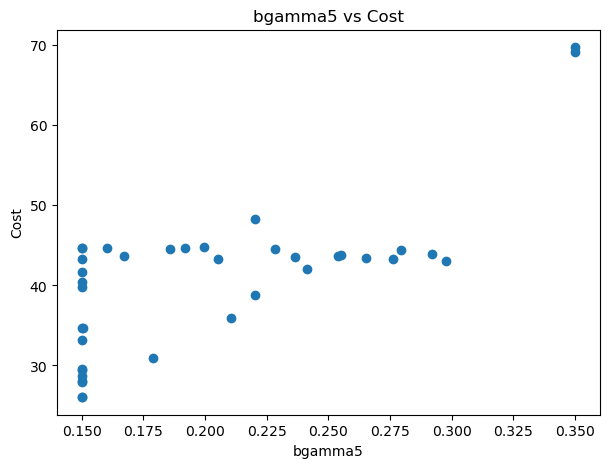

In [45]:
plt.figure(figsize=(7, 5))

plt.scatter(DF_optuna["bgamma5"],
            DF_optuna["Cost"])

plt.xlabel("bgamma5")
plt.ylabel("Cost")
plt.title("bgamma5 vs Cost")

plt.show()

In [46]:
bgamma5_bins = pd.qcut(
    DF_optuna["bgamma5"],
    q=10,
    duplicates="drop"
)

bgamma5_summary = (
    DF_optuna
    .assign(bgamma5_bin=bgamma5_bins)
    .groupby("bgamma5_bin", observed=True)
    .agg(
        Median_Cost_Score=("Cost", "median"),
        Mean_Cost_Score=("Cost", "mean"),
        N=("Cost", "size"),
        Min_bgamma5=("bgamma5", "min"),
        Max_bgamma5=("bgamma5", "max")
    )
)

display(bgamma5_summary)

,Median_Cost_Score,Mean_Cost_Score,N,Min_bgamma5,Max_bgamma5
bgamma5_bin,,,,,
"(0.1499, 0.1504]",33.195317,34.533569,15,0.150000,0.150000
"(0.1504, 0.1824]",39.179690,38.505919,4,0.150541,0.178769
"(0.1824, 0.2064]",44.628892,44.316696,4,0.185964,0.205462
"(0.2064, 0.2274]",38.853880,41.038717,3,0.210393,0.220107
"(0.2274, 0.2547]",43.628125,43.483093,4,0.228261,0.253802
"(0.2547, 0.2832]",43.632042,43.739648,4,0.255338,0.279422
"(0.2832, 0.35]",56.541183,56.470457,4,0.292009,0.350000


# 12. For a given objective, which parameters matter?

In [47]:
objective = "Surface pH Objective"

objective_parameter_corr = (
    DF_optuna[independent_parameters + [objective]]
    .corr(method="spearman")[objective]
    .drop(objective)
    .sort_values()
)

display(
    objective_parameter_corr.to_frame("Spearman Correlation")
)

,Spearman Correlation
akno3s2,-0.688023
Chl2cs1_m,-0.401907
amaxs2,-0.289248
akno3s1,-0.174014
aknh4s1,0.274127
bgamma5s,0.380086
bnit,0.453760
bgamma7,0.558677
reg2,0.598910
wsd,0.610036


# 13. full parameter × objective Spearman matrix

**Spearman matrix** — direction and monotonic effect

Answers: “When this parameter increases, which objectives tend to improve or worsen?”

In [48]:
objective_parameter_corr = pd.DataFrame(
    index=varied_parameter_cols,
    columns=active_objective_cols,
    dtype=float
)

for parameter in varied_parameter_cols:
    for objective in active_objective_cols:

        objective_parameter_corr.loc[parameter, objective] = (
            DF_optuna[[parameter, objective]]
            .corr(method="spearman")
            .iloc[0, 1]
        )
        
display(objective_parameter_corr)

,Surface Temperature Objective,Bottom Temperature Objective,Surface Salinity Objective,Bottom Salinity Objective,Surface pH Objective,Bottom pH Objective,Surface Oxygen Objective,Bottom Oxygen Objective,Surface NO3 Objective,Bottom NO3 Objective,Surface NH4 Objective,Bottom NH4 Objective,Surface Si Objective,Bottom Si Objective,Secchi Depth Objective,SOD Objective
bgamma0,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
wsp,-0.400963,-0.400963,-0.400963,-0.400939,-0.386917,-0.386917,0.386917,-0.386917,-0.333178,0.257944,-0.365421,0.021495,0.365421,0.333178,-0.268692,0.000000
bUmax_nspc0,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
akz1,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
reg1,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
bgamma3,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
reg2,0.016051,0.599250,-0.267522,-0.171204,0.598910,0.526628,0.098097,0.010326,0.175543,0.103260,0.402716,0.542117,-0.423368,-0.449183,-0.516302,0.604073
bfs_nspc0,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000
aksio4s2,-0.400963,-0.400963,-0.400963,-0.400939,-0.386917,-0.386917,0.386917,-0.386917,-0.333178,0.257944,-0.365421,0.021495,0.365421,0.333178,-0.268692,0.000000
pis2,0.400963,0.400963,0.400963,0.400939,0.386917,0.386917,-0.386917,0.386917,0.333178,-0.257944,0.365421,-0.021495,-0.365421,-0.333178,0.268692,0.000000


Some notable patterns/correlations:
* **reg1**: increasing moderately worsens Surface pH performance.
* **akno3s2**: increasing moderately-to-strongly improves both Surface and Bottom pH performance.
* **bgamma5**: increasing strongly worsens pH performance, particularly Surface pH and Bottom pH.
* **wsd**: increasing moderately-to-strongly worsens pH performance in both the surface and bottom
* **bUmax_nspc1**: increasing strongly worsens pH performance, particularly Surface pH and Bottom pH
* **bdenit**: increasing moderately-to-strongly worsens pH performance in both the surface and bottom

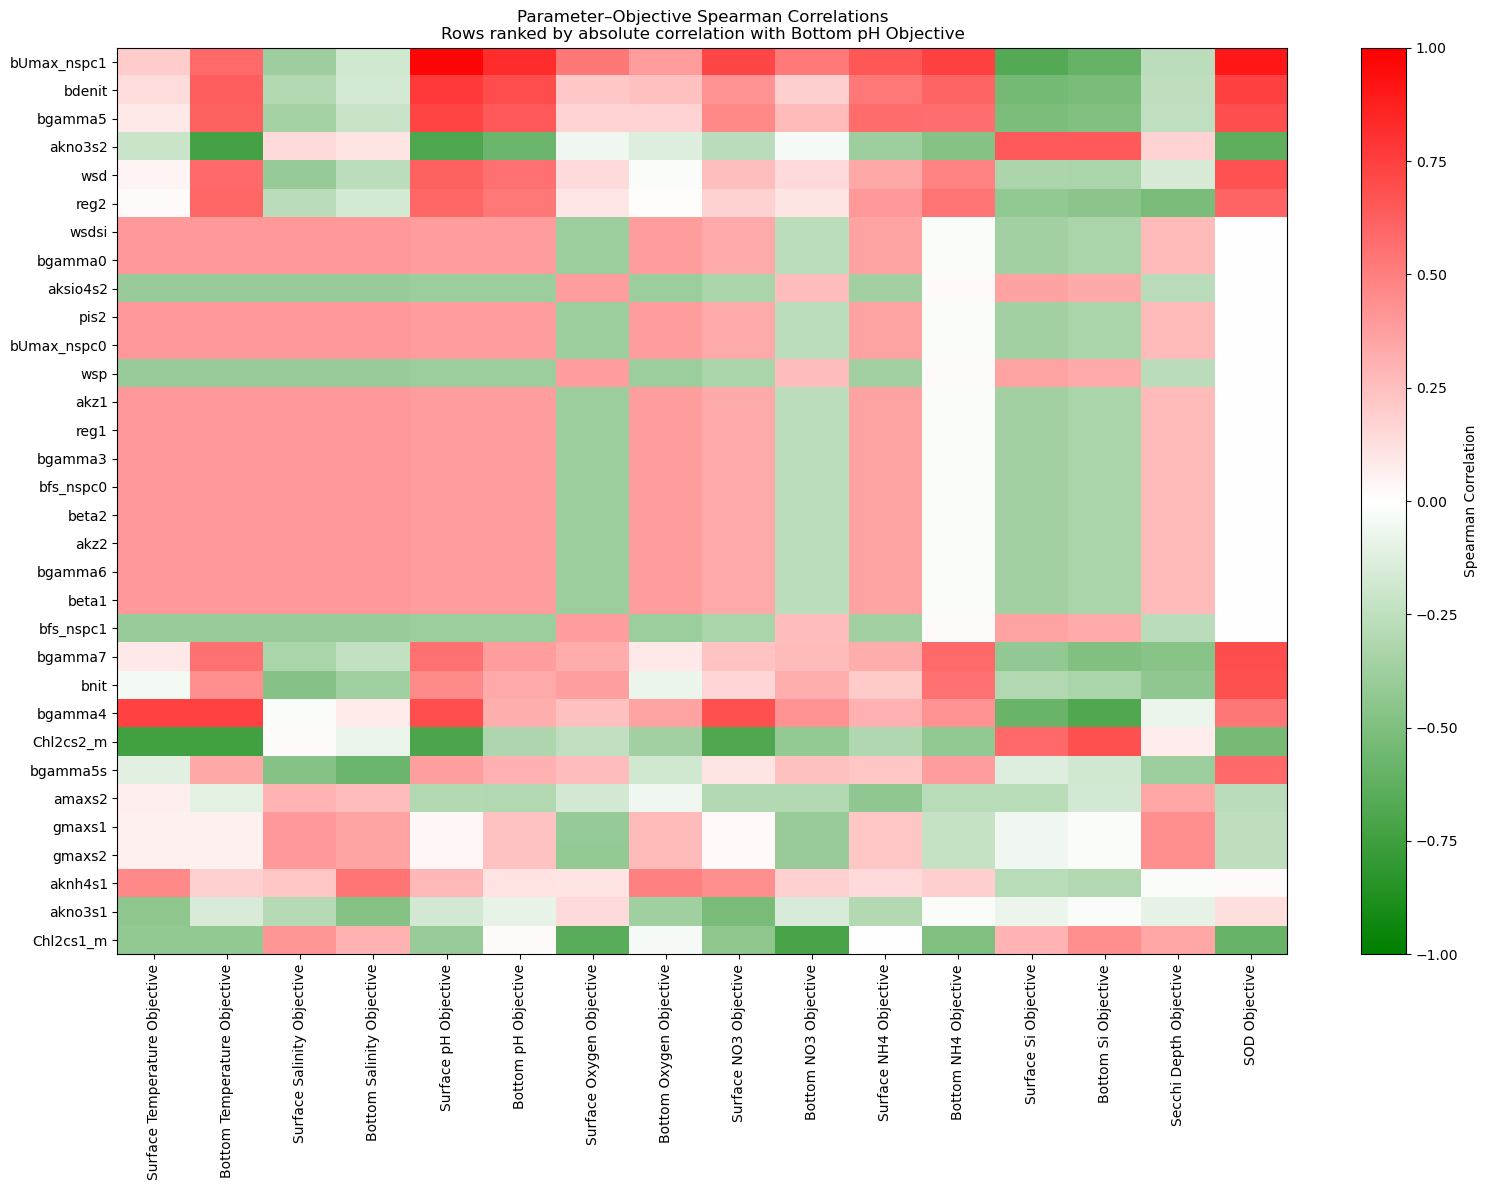

In [49]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# --------------------------------
# Sort parameters by Bottom pH importance
# --------------------------------

rank_objective = "Bottom pH Objective"

objective_parameter_corr_heatmap = (
    objective_parameter_corr
    .loc[
        objective_parameter_corr[rank_objective]
        .abs()
        .sort_values(ascending=False)
        .index
    ]
)

# --------------------------------
# Custom colormap:
# green = improvement when parameter increases
# red   = worsening when parameter increases
# --------------------------------

green_red_cmap = LinearSegmentedColormap.from_list(
    "green_white_red",
    ["green", "white", "red"]
)

# --------------------------------
# Plot heatmap
# --------------------------------

plt.figure(figsize=(16, 12))

plt.imshow(objective_parameter_corr_heatmap,
           aspect="auto",
           vmin=-1,
           vmax=1,
           cmap=green_red_cmap)

plt.colorbar(label="Spearman Correlation")

plt.xticks(range(len(objective_parameter_corr_heatmap.columns)),
           objective_parameter_corr_heatmap.columns,
           rotation=90)

plt.yticks(range(len(objective_parameter_corr_heatmap.index)),
           objective_parameter_corr_heatmap.index)

plt.title("Parameter–Objective Spearman Correlations\n"
          f"Rows ranked by absolute correlation with {rank_objective}")

plt.tight_layout()
plt.show()